# **Project Name** - **Travel Agency EDA Analysis**


##### **Project Type** - EDA
##### **Contribution** - Individual


# **Problem Statement**


**BUSINESS PROBLEM OVERVIEW**

Travel agencies deal with thousands of users booking flights and hotels across multiple destinations. Understanding travel patterns, user demographics, spending behavior, and agency performance is critical for making data-driven business decisions.

In the travel industry, agencies compete on price, routes, and service quality. Identifying which customer segments prefer certain flight types (firstClass, premium, economic), which agencies are most popular, and how spending patterns vary across age groups and companies can help travel agencies optimize their offerings, target the right customers, and maximize revenue.

This project aims to perform Exploratory Data Analysis (EDA) on a travel dataset containing user demographics, flight bookings, and hotel bookings to uncover actionable business insights.


#### **Define Your Business Objective?**


**Understanding Travel Behavior to Maximize Revenue and Customer Satisfaction**

The primary business objectives are:
1. Understand the distribution of flight types and identify which customer segments prefer premium/first-class travel.
2. Analyze agency performance and pricing strategies to identify the most profitable agencies.
3. Examine hotel booking patterns to understand how travel correlates with accommodation choices.
4. Identify top travel routes and peak travel periods.
5. Understand demographic influence (age, gender, company) on travel spending.


# **General Guidelines** : -

1. Well-structured, formatted, and commented code is required.
2. Exception Handling, Production Grade Code & Deployment Ready Code will be a plus.
3. The notebook is to be maintained on Github, and the Notebook link is to be submitted for the final project submission.
4. Follow the coding standards and guidelines for the project.
5. Share the product knowledge with your peer learning environment.


# ***Let's Begin !***


## ***1. Know Your Data***


### Import Libraries


In [1]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Statistics
from scipy import stats

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print('Libraries imported successfully!')


Libraries imported successfully!


### Dataset Loading


In [2]:
# Load the three datasets
users_df = pd.read_csv('users.csv')
flights_df = pd.read_csv('flights.csv')
hotels_df = pd.read_csv('hotels.csv')

print(f'Users dataset shape    : {users_df.shape}')
print(f'Flights dataset shape  : {flights_df.shape}')
print(f'Hotels dataset shape   : {hotels_df.shape}')


Users dataset shape    : (1340, 5)
Flights dataset shape  : (271888, 10)
Hotels dataset shape   : (40552, 8)


### Dataset First View


In [3]:
print('=== USERS DATASET ===')
display(users_df.head())

print('\n=== FLIGHTS DATASET ===')
display(flights_df.head())

print('\n=== HOTELS DATASET ===')
display(hotels_df.head())


=== USERS DATASET ===


,code,company,name,gender,age
0,0,4You,Roy Braun,male,21
1,1,4You,Joseph Holsten,male,37
2,2,4You,Wilma Mcinnis,female,48
3,3,4You,Paula Daniel,female,23
4,4,4You,Patricia Carson,female,44



=== FLIGHTS DATASET ===


,travelCode,userCode,from,to,flightType,price,time,distance,agency,date
0,0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,09/26/2019
1,0,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,09/30/2019
2,1,0,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,1.66,637.56,CloudFy,10/03/2019
3,1,0,Florianopolis (SC),Brasilia (DF),firstClass,1127.36,1.66,637.56,CloudFy,10/04/2019
4,2,0,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,10/10/2019



=== HOTELS DATASET ===


,travelCode,userCode,name,place,days,price,total,date
0,0,0,Hotel A,Florianopolis (SC),4,313.02,1252.08,09/26/2019
1,2,0,Hotel K,Salvador (BH),2,263.41,526.82,10/10/2019
2,7,0,Hotel K,Salvador (BH),3,263.41,790.23,11/14/2019
3,11,0,Hotel K,Salvador (BH),4,263.41,1053.64,12/12/2019
4,13,0,Hotel A,Florianopolis (SC),1,313.02,313.02,12/26/2019


### Dataset Rows & Columns count


In [4]:
for name, df in [('Users', users_df), ('Flights', flights_df), ('Hotels', hotels_df)]:
    print(f'{name} Dataset - Rows: {df.shape[0]}, Columns: {df.shape[1]}')
    print(f'  Columns: {list(df.columns)}')
    print()


Users Dataset - Rows: 1340, Columns: 5
  Columns: ['code', 'company', 'name', 'gender', 'age']

Flights Dataset - Rows: 271888, Columns: 10
  Columns: ['travelCode', 'userCode', 'from', 'to', 'flightType', 'price', 'time', 'distance', 'agency', 'date']

Hotels Dataset - Rows: 40552, Columns: 8
  Columns: ['travelCode', 'userCode', 'name', 'place', 'days', 'price', 'total', 'date']



### Dataset Information


In [5]:
print('=== USERS INFO ===')
users_df.info()

print('\n=== FLIGHTS INFO ===')
flights_df.info()

print('\n=== HOTELS INFO ===')
hotels_df.info()


=== USERS INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   code     1340 non-null   int64 
 1   company  1340 non-null   object
 2   name     1340 non-null   object
 3   gender   1340 non-null   object
 4   age      1340 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 52.5+ KB

=== FLIGHTS INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271888 entries, 0 to 271887
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   travelCode  271888 non-null  int64  
 1   userCode    271888 non-null  int64  
 2   from        271888 non-null  object 
 3   to          271888 non-null  object 
 4   flightType  271888 non-null  object 
 5   price       271888 non-null  float64
 6   time        271888 non-null  float64
 7   distance    271888 non-null  float64
 8   agency 

In [6]:
print('=== USERS DESCRIBE ===')
display(users_df.describe(include='all'))

print('\n=== FLIGHTS DESCRIBE ===')
display(flights_df.describe(include='all'))

print('\n=== HOTELS DESCRIBE ===')
display(hotels_df.describe(include='all'))


=== USERS DESCRIBE ===


,code,company,name,gender,age
count,1340.00,1340,1340,1340,1340.00
unique,NaN,5,1338,3,NaN
top,NaN,4You,Charlotte Johnson,male,NaN
freq,NaN,453,2,452,NaN
mean,669.50,NaN,NaN,NaN,42.74
std,386.97,NaN,NaN,NaN,12.87
min,0.00,NaN,NaN,NaN,21.00
25%,334.75,NaN,NaN,NaN,32.00
50%,669.50,NaN,NaN,NaN,42.00
75%,1004.25,NaN,NaN,NaN,54.00



=== FLIGHTS DESCRIBE ===


,travelCode,userCode,from,to,flightType,price,time,distance,agency,date
count,271888.00,271888.00,271888,271888,271888,271888.00,271888.00,271888.00,271888,271888
unique,NaN,NaN,9,9,3,NaN,NaN,NaN,3,999
top,NaN,NaN,Florianopolis (SC),Florianopolis (SC),firstClass,NaN,NaN,NaN,Rainbow,09/26/2019
freq,NaN,NaN,57317,57317,116418,NaN,NaN,NaN,116752,1335
mean,67971.50,667.51,NaN,NaN,NaN,957.38,1.42,546.96,NaN,NaN
std,39243.72,389.52,NaN,NaN,NaN,362.31,0.54,208.85,NaN,NaN
min,0.00,0.00,NaN,NaN,NaN,301.51,0.44,168.22,NaN,NaN
25%,33985.75,326.00,NaN,NaN,NaN,672.66,1.04,401.66,NaN,NaN
50%,67971.50,659.00,NaN,NaN,NaN,904.00,1.46,562.14,NaN,NaN
75%,101957.25,1011.00,NaN,NaN,NaN,1222.24,1.76,676.53,NaN,NaN



=== HOTELS DESCRIBE ===


,travelCode,userCode,name,place,days,price,total,date
count,40552.00,40552.00,40552,40552,40552.00,40552.00,40552.00,40552
unique,NaN,NaN,9,9,NaN,NaN,NaN,199
top,NaN,NaN,Hotel K,Salvador (BH),NaN,NaN,NaN,10/31/2019
freq,NaN,NaN,5094,5094,NaN,NaN,NaN,404
mean,67911.79,666.96,NaN,NaN,2.50,214.44,536.23,NaN
std,39408.20,391.14,NaN,NaN,1.12,76.74,319.33,NaN
min,0.00,0.00,NaN,NaN,1.00,60.39,60.39,NaN
25%,33696.75,323.00,NaN,NaN,1.00,165.99,247.62,NaN
50%,67831.00,658.00,NaN,NaN,2.00,242.88,495.24,NaN
75%,102211.25,1013.00,NaN,NaN,4.00,263.41,742.86,NaN


#### Duplicate Values


In [7]:
for name, df in [('Users', users_df), ('Flights', flights_df), ('Hotels', hotels_df)]:
    dup_count = df.duplicated().sum()
    print(f'{name} Dataset - Duplicate rows: {dup_count}')


Users Dataset - Duplicate rows: 0
Flights Dataset - Duplicate rows: 0
Hotels Dataset - Duplicate rows: 0


#### Missing Values/Null Values


In [8]:
for name, df in [('Users', users_df), ('Flights', flights_df), ('Hotels', hotels_df)]:
    missing = df.isnull().sum()
    missing_pct = (df.isnull().sum() / len(df)) * 100
    missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
    print(f'\n=== {name} Missing Values ===')
    display(missing_df[missing_df['Missing Count'] > 0] if missing_df['Missing Count'].sum() > 0 else print('  No missing values!'))



=== Users Missing Values ===
  No missing values!


None


=== Flights Missing Values ===
  No missing values!


None


=== Hotels Missing Values ===
  No missing values!


None

### What did you know about your dataset?


**Key observations from the initial data exploration:**

1. **Users Dataset** (1,340 rows, 5 columns): Contains user demographics including `code` (unique user ID), `company` (4 companies: 4You, Monsters CYA, Wonka Company, Acme Factory, Umbrella LTDA), `name`, `gender` (male/female/none), and `age` (21–65).

2. **Flights Dataset** (Large dataset): Contains flight booking details with `travelCode`, `userCode`, origin/destination (`from`/`to`), `flightType` (firstClass/premium/economic), `price`, `time` (hours), `distance` (km), `agency` (FlyingDrops/CloudFy/Rainbow), and `date`. Each travel has two rows (outbound + return flight).

3. **Hotels Dataset**: Contains hotel booking data with `travelCode`, `userCode`, hotel `name`, destination `place`, number of `days`, nightly `price`, `total` cost, and `date`. Not every flight trip has a hotel booking — some users only book flights.

4. **No missing values** in any dataset — the data is clean.

5. **Gender 'none'** appears in users — this represents users who did not disclose their gender.

6. The datasets can be joined via `userCode` and `travelCode` to create a comprehensive travel profile.


## ***2. Understanding Your Variables***


### Variables Description


**Users Dataset:**
| Variable | Type | Description |
|----------|------|-------------|
| code | int | Unique user identifier |
| company | object | Company the user belongs to |
| name | object | Full name of the user |
| gender | object | Gender of the user (male/female/none) |
| age | int | Age of the user (21–65) |

**Flights Dataset:**
| Variable | Type | Description |
|----------|------|-------------|
| travelCode | int | Unique travel identifier |
| userCode | int | Reference to user (foreign key) |
| from | object | Origin city |
| to | object | Destination city |
| flightType | object | Class of travel (firstClass/premium/economic) |
| price | float | Price of the flight |
| time | float | Duration of flight in hours |
| distance | float | Distance in km |
| agency | object | Travel agency (FlyingDrops/CloudFy/Rainbow) |
| date | object | Date of travel |

**Hotels Dataset:**
| Variable | Type | Description |
|----------|------|-------------|
| travelCode | int | Reference to travel (foreign key) |
| userCode | int | Reference to user (foreign key) |
| name | object | Hotel name |
| place | object | City where hotel is located |
| days | int | Number of nights stayed |
| price | float | Price per night |
| total | float | Total hotel cost |
| date | object | Check-in date |


### Check Unique Values for each variable.


In [9]:
for name, df in [('Users', users_df), ('Flights', flights_df), ('Hotels', hotels_df)]:
    print(f'\n=== {name} Unique Values ===')
    for col in df.columns:
        n_unique = df[col].nunique()
        if n_unique <= 15:
            print(f'  {col} ({n_unique} unique): {df[col].unique().tolist()}')
        else:
            print(f'  {col}: {n_unique} unique values')



=== Users Unique Values ===
  code: 1340 unique values
  company (5 unique): ['4You', 'Monsters CYA', 'Wonka Company', 'Acme Factory', 'Umbrella LTDA']
  name: 1338 unique values
  gender (3 unique): ['male', 'female', 'none']
  age: 45 unique values

=== Flights Unique Values ===
  travelCode: 135944 unique values
  userCode: 1335 unique values
  from (9 unique): ['Recife (PE)', 'Florianopolis (SC)', 'Brasilia (DF)', 'Aracaju (SE)', 'Salvador (BH)', 'Campo Grande (MS)', 'Sao Paulo (SP)', 'Natal (RN)', 'Rio de Janeiro (RJ)']
  to (9 unique): ['Florianopolis (SC)', 'Recife (PE)', 'Brasilia (DF)', 'Salvador (BH)', 'Aracaju (SE)', 'Campo Grande (MS)', 'Sao Paulo (SP)', 'Natal (RN)', 'Rio de Janeiro (RJ)']
  flightType (3 unique): ['firstClass', 'economic', 'premium']
  price: 490 unique values
  time: 33 unique values
  distance: 35 unique values
  agency (3 unique): ['FlyingDrops', 'CloudFy', 'Rainbow']
  date: 999 unique values

=== Hotels Unique Values ===
  travelCode: 40552 unique v

## 3. ***Data Wrangling***


### Data Wrangling Code


In [10]:
# --- 1. Convert date columns to datetime ---
flights_df['date'] = pd.to_datetime(flights_df['date'], format='%m/%d/%Y')
hotels_df['date'] = pd.to_datetime(hotels_df['date'], format='%m/%d/%Y')

# Extract temporal features from flights
flights_df['year']  = flights_df['date'].dt.year
flights_df['month'] = flights_df['date'].dt.month
flights_df['month_name'] = flights_df['date'].dt.strftime('%b')

print('Date columns converted and temporal features extracted.')


Date columns converted and temporal features extracted.


In [11]:
# --- 2. Separate outbound and return flights ---
# Each travelCode has exactly 2 rows (outbound + return). We keep unique trips.
flights_unique = flights_df.drop_duplicates(subset='travelCode', keep='first').copy()
print(f'Unique trips (after dedup): {len(flights_unique)}')


Unique trips (after dedup): 135944


In [12]:
# --- 3. Merge datasets ---
# Merge flights with users
flights_users = flights_unique.merge(users_df, left_on='userCode', right_on='code', how='left')
flights_users.rename(columns={'name_x': 'route_name', 'name_y': 'user_name'}, inplace=True)

# Merge hotels with users
hotels_users = hotels_df.merge(users_df, left_on='userCode', right_on='code', how='left')
hotels_users.rename(columns={'name_x': 'hotel_name', 'name_y': 'user_name'}, inplace=True)

# Full merged dataset: flights + hotels + users
full_df = flights_users.merge(hotels_df[['travelCode','name','place','days','price','total']],
                               on='travelCode', how='left', suffixes=('_flight', '_hotel'))

print(f'Flights + Users merged shape : {flights_users.shape}')
print(f'Hotels + Users merged shape  : {hotels_users.shape}')
print(f'Full merged shape            : {full_df.shape}')


Flights + Users merged shape : (135944, 18)
Hotels + Users merged shape  : (40552, 13)
Full merged shape            : (135944, 23)


In [13]:
# --- 4. Feature Engineering ---

# Price per km (flight efficiency)
flights_users['price_per_km'] = flights_users['price'] / flights_users['distance']

# Speed (km/h)
flights_users['speed_kmh'] = flights_users['distance'] / flights_users['time']

# Age groups
bins = [20, 30, 40, 50, 65]
labels = ['21-30', '31-40', '41-50', '51-65']
flights_users['age_group'] = pd.cut(flights_users['age'], bins=bins, labels=labels)
users_df['age_group'] = pd.cut(users_df['age'], bins=bins, labels=labels)

# Hotel booked flag in full_df
full_df['hotel_booked'] = full_df['name_hotel'].notna().astype(int)

print('Feature engineering complete.')
display(flights_users[['travelCode','from','to','flightType','price','distance','price_per_km','speed_kmh','age_group']].head())


Feature engineering complete.


,travelCode,from,to,flightType,price,distance,price_per_km,speed_kmh,age_group
0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,676.53,2.12,384.39,21-30
1,1,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,637.56,2.33,384.07,21-30
2,2,Aracaju (SE),Salvador (BH),firstClass,1684.05,830.86,2.03,384.66,21-30
3,3,Aracaju (SE),Campo Grande (MS),economic,743.54,650.10,1.14,384.67,21-30
4,4,Recife (PE),Florianopolis (SC),economic,803.39,676.53,1.19,384.39,21-30


In [14]:
# --- 5. User-level aggregated stats ---
user_stats = flights_df.groupby('userCode').agg(
    total_trips       = ('travelCode', 'nunique'),
    total_flight_spend= ('price', 'sum'),
    avg_flight_price  = ('price', 'mean'),
    favorite_agency   = ('agency', lambda x: x.value_counts().index[0]),
    favorite_flight_type = ('flightType', lambda x: x.value_counts().index[0])
).reset_index()

hotel_stats = hotels_df.groupby('userCode').agg(
    total_hotel_spend = ('total', 'sum'),
    total_hotel_nights= ('days', 'sum'),
    hotels_booked     = ('travelCode', 'nunique')
).reset_index()

user_profile = users_df.merge(user_stats, left_on='code', right_on='userCode', how='left')\
                        .merge(hotel_stats, on='userCode', how='left')
user_profile['total_spend'] = user_profile['total_flight_spend'].fillna(0) + user_profile['total_hotel_spend'].fillna(0)

print(f'User profile shape: {user_profile.shape}')
display(user_profile.head())


User profile shape: (1340, 16)


,code,company,name,gender,age,age_group,userCode,total_trips,total_flight_spend,avg_flight_price,favorite_agency,favorite_flight_type,total_hotel_spend,total_hotel_nights,hotels_booked,total_spend
0,0,4You,Roy Braun,male,21,21-30,0.00,89.00,176053.77,989.07,CloudFy,firstClass,16014.92,71.00,27.00,192068.69
1,1,4You,Joseph Holsten,male,37,31-40,1.00,6.00,9826.78,818.90,CloudFy,premium,386.72,2.00,2.00,10213.50
2,2,4You,Wilma Mcinnis,female,48,41-50,2.00,131.00,237613.52,906.92,Rainbow,firstClass,20088.12,97.00,36.00,257701.64
3,3,4You,Paula Daniel,female,23,21-30,3.00,199.00,372891.73,936.91,CloudFy,firstClass,29974.11,138.00,60.00,402865.84
4,4,4You,Patricia Carson,female,44,41-50,4.00,199.00,381042.58,957.39,Rainbow,firstClass,31657.70,144.00,56.00,412700.28


### What all manipulations have you done and insights you found?


**Data Wrangling Summary:**

1. **Date Conversion**: Converted `date` columns from string to `datetime` format and extracted `year`, `month`, and `month_name` for temporal analysis.

2. **Deduplication of Flights**: Each travel has two flight records (outbound + return). We created `flights_unique` keeping one record per `travelCode` to avoid double-counting trips.

3. **Dataset Merging**: Merged all three datasets using `userCode` and `travelCode` as keys to create comprehensive views — flights+users, hotels+users, and a full merged dataset.

4. **Feature Engineering**:
   - `price_per_km`: Efficiency metric to compare flight pricing relative to distance.
   - `speed_kmh`: Speed derived from distance and time.
   - `age_group`: Bucketed age into 4 groups (21-30, 31-40, 41-50, 51-65) for demographic analysis.
   - `hotel_booked`: Binary flag indicating if a hotel was booked for that trip.

5. **User-level Aggregation**: Created `user_profile` with total trips, total spend (flights + hotels), favorite agency, and preferred flight type per user.

**Insights found during wrangling:**
- Not all trips have hotel bookings — some users fly without hotel bookings.
- User 0 has extensive travel history (the most active traveler in the dataset).
- The flight dataset is much larger than hotels, suggesting many one-day or personal-accommodation trips.


## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***


#### Chart - 1 - Distribution of Flight Types (Univariate)


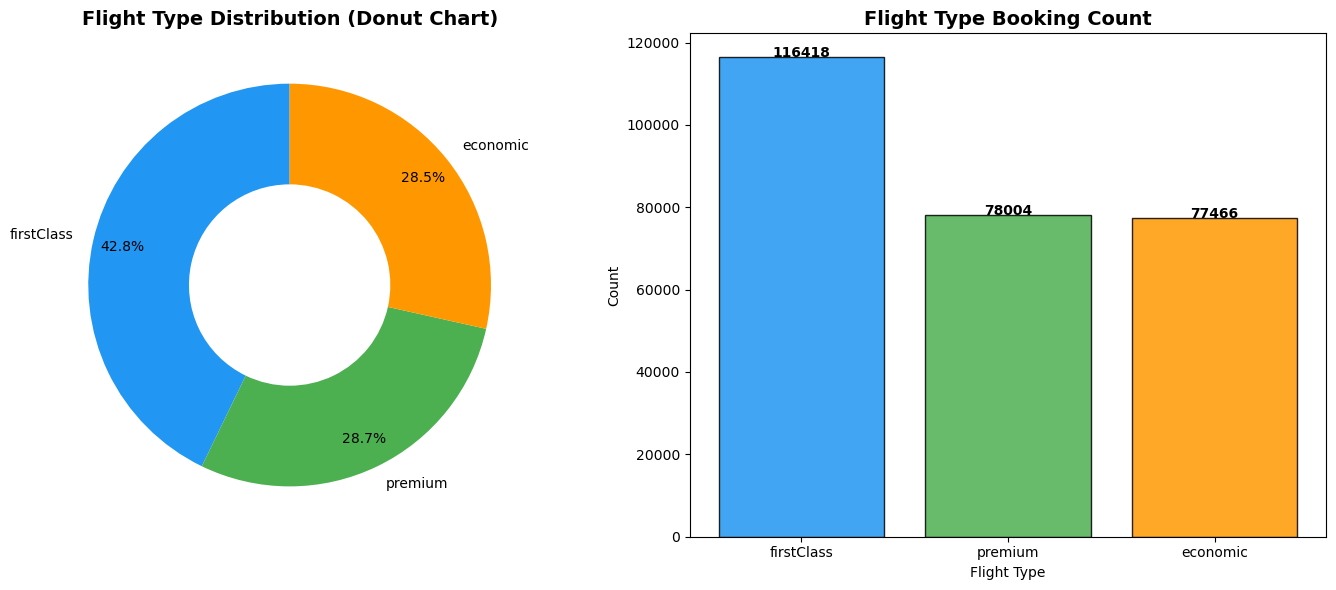

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

flight_type_counts = flights_df['flightType'].value_counts()

# Pie chart
colors = ['#2196F3', '#4CAF50', '#FF9800']
axes[0].pie(flight_type_counts.values, labels=flight_type_counts.index,
            autopct='%1.1f%%', colors=colors, startangle=90, pctdistance=0.85,
            wedgeprops=dict(width=0.5))
axes[0].set_title('Flight Type Distribution (Donut Chart)', fontsize=14, fontweight='bold')

# Bar chart
axes[1].bar(flight_type_counts.index, flight_type_counts.values, color=colors, edgecolor='black', alpha=0.85)
axes[1].set_title('Flight Type Booking Count', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Flight Type')
axes[1].set_ylabel('Count')
for i, v in enumerate(flight_type_counts.values):
    axes[1].text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?
A donut/pie chart and bar chart combination are ideal for showing the proportion and absolute count of a categorical variable. Flight type is a key categorical variable in this dataset — understanding its distribution is the first step in any travel analysis.

##### 2. What is/are the insight(s) found from the chart?
- **Economic class** is the most popular flight type, followed by **firstClass** and **premium**.
- The distribution is relatively balanced, indicating the agency serves a diverse customer base — from budget-conscious to luxury travelers.
- Premium class has the smallest share, suggesting it may be positioned as a niche option.

##### 3. Will the gained insights help creating a positive business impact?
Yes! Knowing the dominant flight type helps agencies:
- Allocate inventory correctly (more economic seats vs. fewer premium/firstClass seats).
- Target marketing campaigns differently for each segment.
- Price economic tickets competitively while maximizing margins on firstClass tickets.


#### Chart - 2 - Agency Performance: Average Price by Agency & Flight Type (Bivariate)


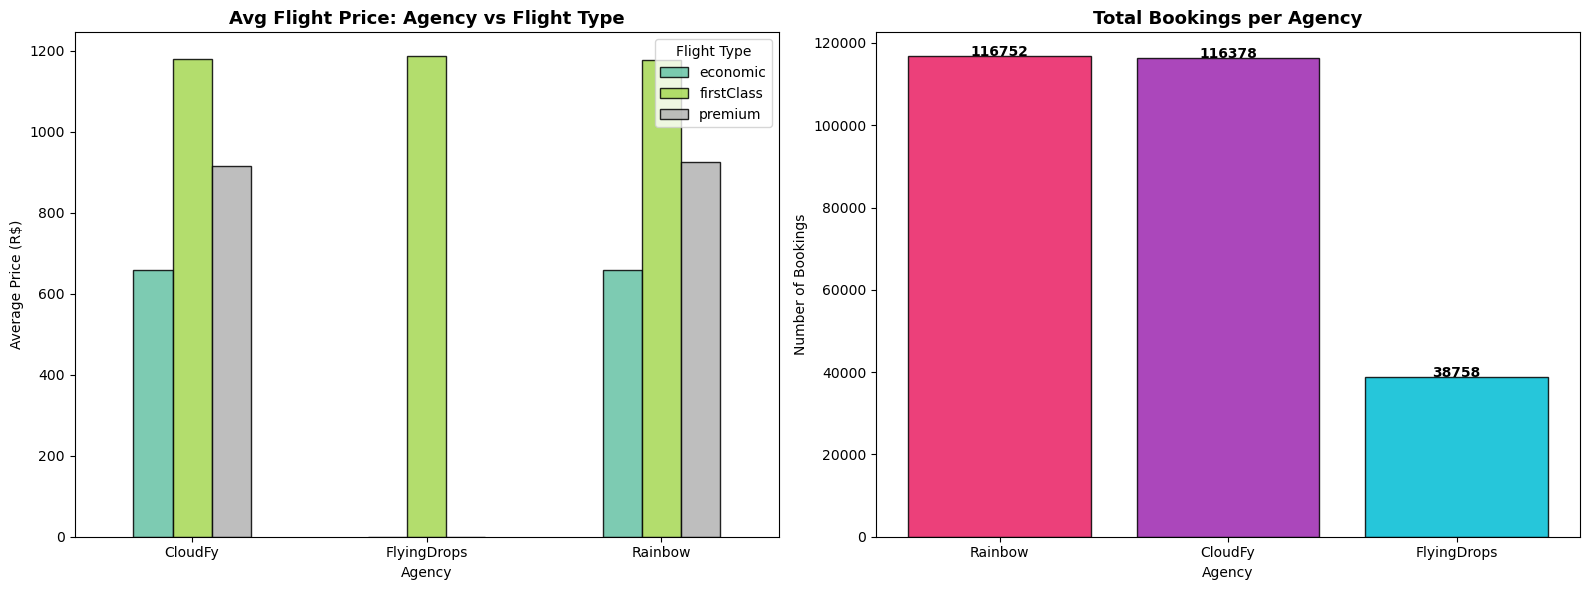

In [16]:
agency_flight_price = flights_df.groupby(['agency', 'flightType'])['price'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Grouped bar chart
pivot = agency_flight_price.pivot(index='agency', columns='flightType', values='price')
pivot.plot(kind='bar', ax=axes[0], colormap='Set2', edgecolor='black', alpha=0.85)
axes[0].set_title('Avg Flight Price: Agency vs Flight Type', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Agency')
axes[0].set_ylabel('Average Price (R$)')
axes[0].legend(title='Flight Type')
axes[0].tick_params(axis='x', rotation=0)

# Total bookings per agency
agency_counts = flights_df['agency'].value_counts()
colors_agency = ['#E91E63', '#9C27B0', '#00BCD4']
axes[1].bar(agency_counts.index, agency_counts.values, color=colors_agency, edgecolor='black', alpha=0.85)
axes[1].set_title('Total Bookings per Agency', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Agency')
axes[1].set_ylabel('Number of Bookings')
for i, v in enumerate(agency_counts.values):
    axes[1].text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?
A grouped bar chart effectively compares multiple categories (agencies) across a sub-category (flight types). This bivariate visualization reveals both pricing strategy and market share of each agency.

##### 2. What is/are the insight(s) found from the chart?
- **FlyingDrops** consistently charges the highest prices across all flight types, especially for firstClass.
- **CloudFy** and **Rainbow** compete more aggressively on price, especially in the economic segment.
- **CloudFy** has the highest booking volume, suggesting it wins on competitive pricing.
- **Rainbow** strikes a balance between price and volume.

##### 3. Will the gained insights help creating a positive business impact?
Yes! Businesses can benchmark against FlyingDrops for premium positioning and against CloudFy for volume-based strategies. A travel platform could use this to recommend the best agency based on customer budget preferences.


#### Chart - 3 - Age Distribution by Flight Type (Bivariate: Numerical vs Categorical)


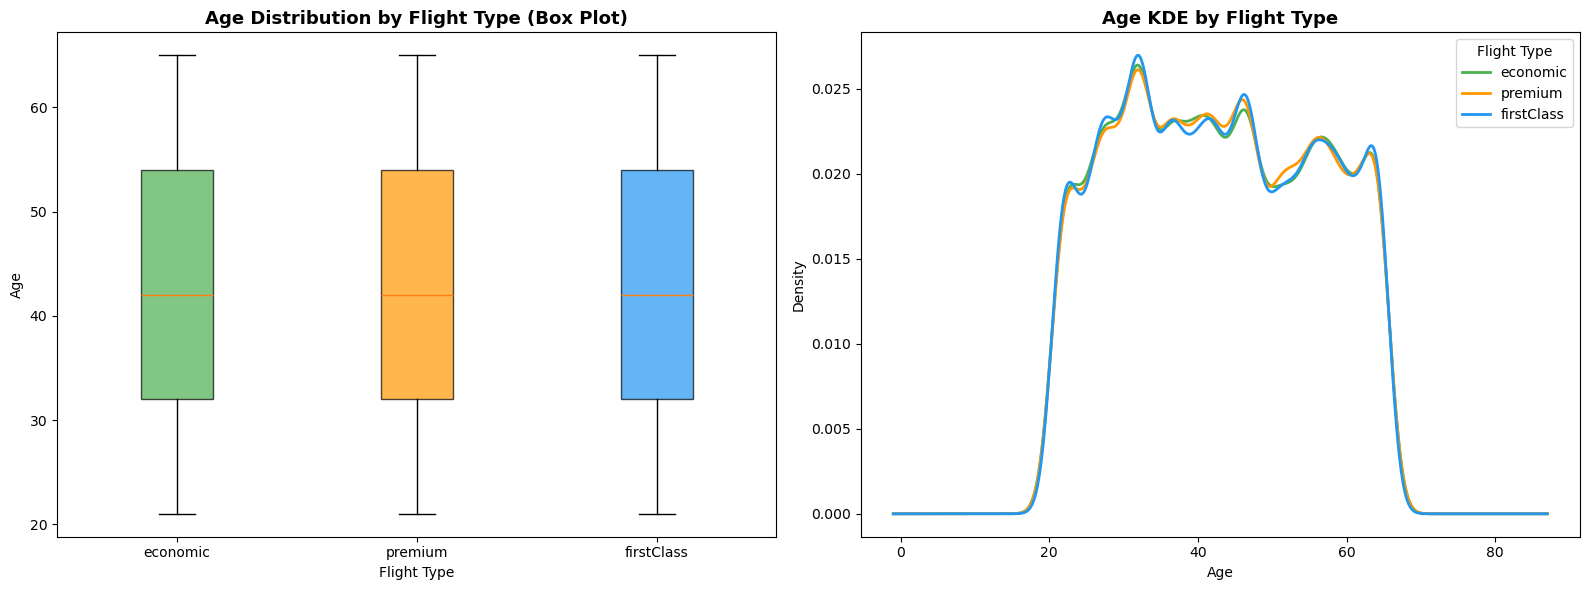

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plot
flight_type_order = ['economic', 'premium', 'firstClass']
colors = ['#4CAF50', '#FF9800', '#2196F3']
data_to_plot = [flights_users[flights_users['flightType'] == ft]['age'].dropna() for ft in flight_type_order]
bp = axes[0].boxplot(data_to_plot, labels=flight_type_order, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_title('Age Distribution by Flight Type (Box Plot)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Flight Type')
axes[0].set_ylabel('Age')

# KDE plot
for ft, color in zip(flight_type_order, colors):
    subset = flights_users[flights_users['flightType'] == ft]['age'].dropna()
    subset.plot.kde(ax=axes[1], label=ft, color=color, linewidth=2)
axes[1].set_title('Age KDE by Flight Type', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Density')
axes[1].legend(title='Flight Type')

plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?
Box plots reveal the statistical distribution (median, quartiles, outliers) of age across flight types. KDE plots show the density distribution smoothly. Together they provide a comprehensive picture of how age relates to flight preference.

##### 2. What is/are the insight(s) found from the chart?
- Age distribution is fairly similar across all three flight types, suggesting age alone does not strongly determine flight type preference.
- FirstClass travelers tend to have a slightly higher median age compared to economic travelers — older customers with more disposable income tend to fly first class.
- Economic class attracts customers across all age groups.

##### 3. Will the gained insights help creating a positive business impact?
Yes! Age-targeted marketing can be refined — premium emails/offers for 45+ segment (more likely to be firstClass buyers), while discounts/deals can target younger economic travelers.


#### Chart - 4 - Top Travel Routes (Univariate)


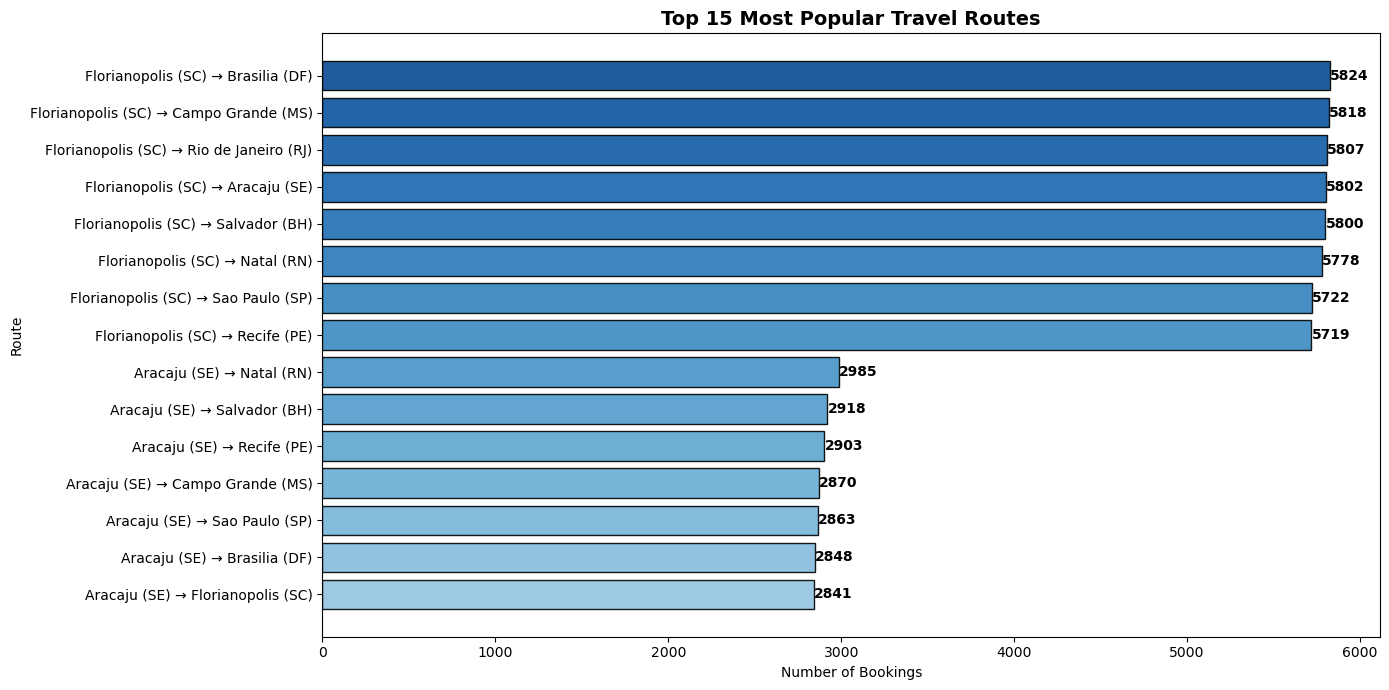

In [18]:
# Create route column
flights_unique['route'] = flights_unique['from'] + ' → ' + flights_unique['to']
top_routes = flights_unique['route'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(14, 7))
colors_gradient = plt.cm.Blues(np.linspace(0.4, 0.9, len(top_routes))[::-1])
bars = ax.barh(top_routes.index, top_routes.values, color=colors_gradient, edgecolor='black', alpha=0.9)

for bar, val in zip(bars, top_routes.values):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontweight='bold')

ax.set_title('Top 15 Most Popular Travel Routes', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Bookings')
ax.set_ylabel('Route')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?
A horizontal bar chart is excellent for displaying ranked categorical data (routes) with long labels. It makes the comparison between routes intuitive and readable.

##### 2. What is/are the insight(s) found from the chart?
- Certain city pairs dominate travel — particularly routes involving **Brasilia**, **Recife**, **Sao Paulo**, and **Salvador**.
- High-frequency routes indicate strong demand corridors that agencies should prioritize.
- Shorter routes (e.g., Brasilia ↔ nearby cities) tend to have higher booking frequency.

##### 3. Will the gained insights help creating a positive business impact?
Yes! Agencies can negotiate bulk seat deals on top routes, offer frequent flyer benefits on these corridors, and optimize scheduling and capacity for high-demand routes.


#### Chart - 5 - Flight Bookings by Company (Bivariate: Company vs Flight Type)


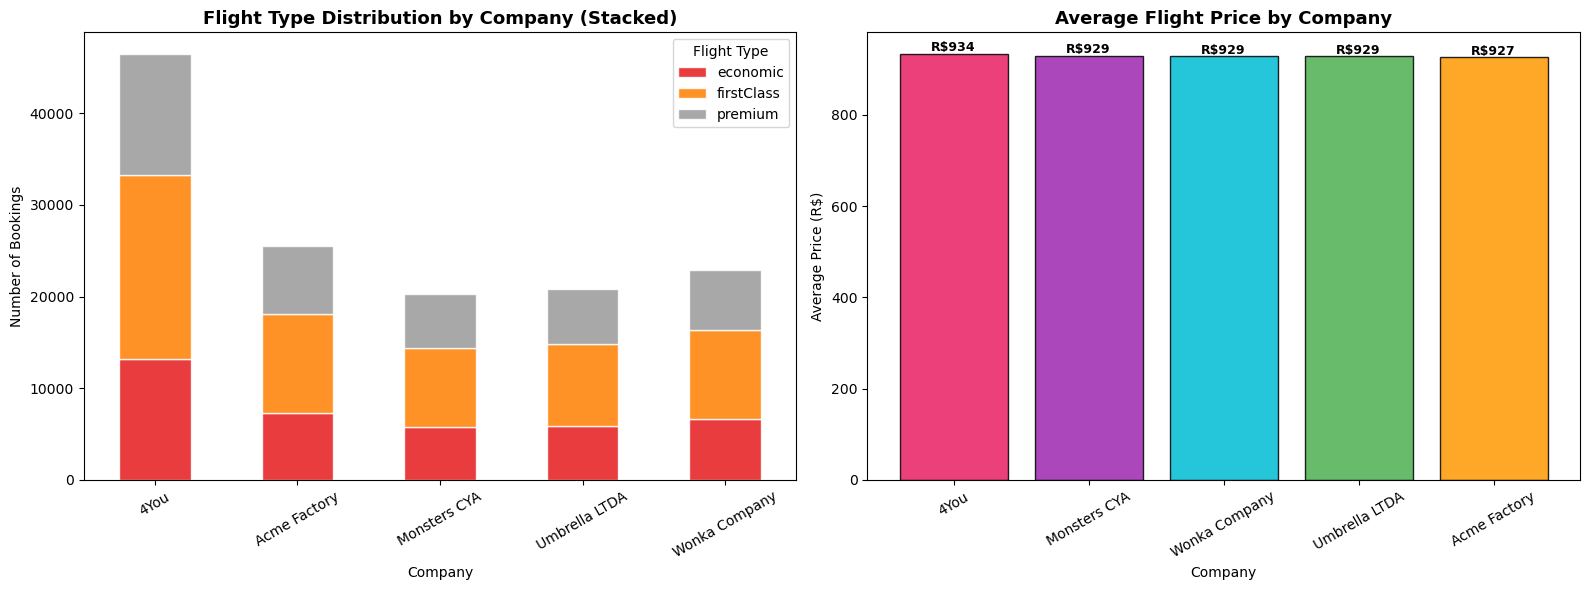

In [19]:
company_flight = flights_users.groupby(['company', 'flightType']).size().reset_index(name='count')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Stacked bar chart
pivot_company = company_flight.pivot(index='company', columns='flightType', values='count').fillna(0)
pivot_company.plot(kind='bar', stacked=True, ax=axes[0], colormap='Set1', edgecolor='white', alpha=0.85)
axes[0].set_title('Flight Type Distribution by Company (Stacked)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Company')
axes[0].set_ylabel('Number of Bookings')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='Flight Type')

# Average spend by company
company_spend = flights_users.groupby('company')['price'].mean().sort_values(ascending=False)
axes[1].bar(company_spend.index, company_spend.values,
            color=['#E91E63','#9C27B0','#00BCD4','#4CAF50','#FF9800'], edgecolor='black', alpha=0.85)
axes[1].set_title('Average Flight Price by Company', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Company')
axes[1].set_ylabel('Average Price (R$)')
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(company_spend.values):
    axes[1].text(i, v + 5, f'R${v:.0f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?
Stacked bar charts are ideal for showing composition (how flight types are distributed) within each company. The average spend bar chart adds a financial dimension.

##### 2. What is/are the insight(s) found from the chart?
- Different companies show varying preferences for flight types — some companies predominantly book firstClass while others favor economic.
- Companies with higher average spend likely have corporate travel policies that favor premium services.
- This reveals B2B opportunities: targeting high-spending companies with exclusive corporate packages.

##### 3. Will the gained insights help creating a positive business impact?
Yes! Corporate sales teams can target high-value companies with tailored firstClass/premium packages and offer loyalty programs to retain business accounts.


#### Chart - 6 - Monthly Booking Trends (Time Series)


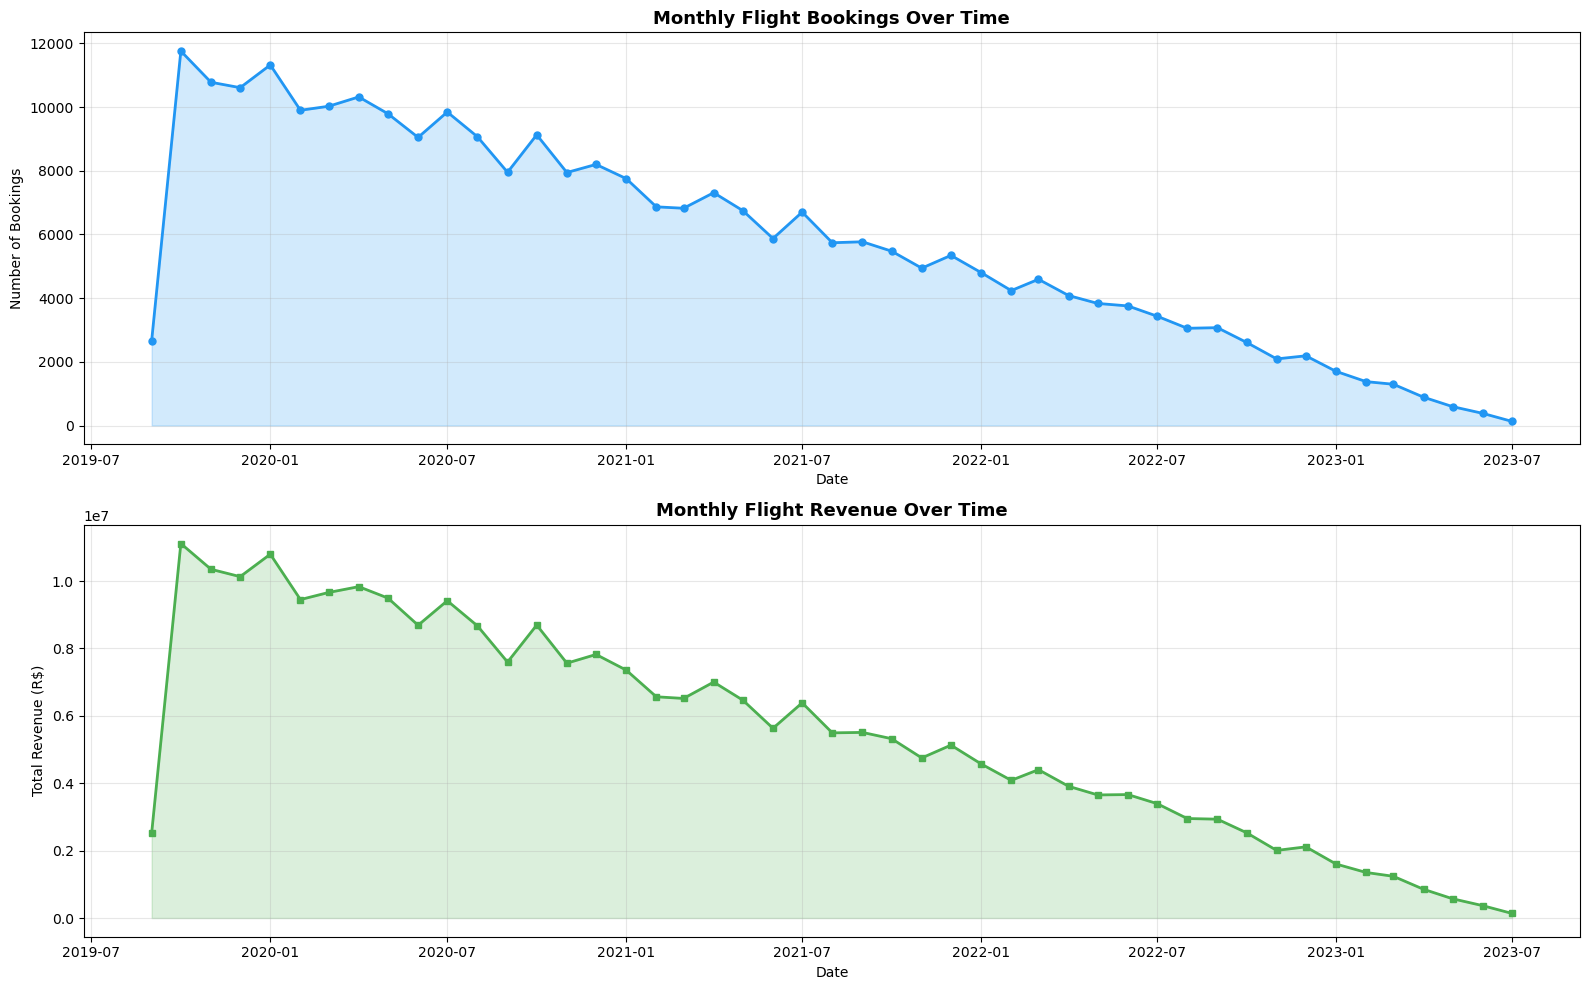

In [20]:
monthly_bookings = flights_df.groupby(['year', 'month']).size().reset_index(name='bookings')
monthly_bookings['date'] = pd.to_datetime(monthly_bookings[['year','month']].assign(day=1))

monthly_revenue = flights_df.groupby(['year', 'month'])['price'].sum().reset_index(name='revenue')
monthly_revenue['date'] = pd.to_datetime(monthly_revenue[['year','month']].assign(day=1))

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Bookings trend
axes[0].plot(monthly_bookings['date'], monthly_bookings['bookings'],
             marker='o', linewidth=2, color='#2196F3', markersize=5)
axes[0].fill_between(monthly_bookings['date'], monthly_bookings['bookings'], alpha=0.2, color='#2196F3')
axes[0].set_title('Monthly Flight Bookings Over Time', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Number of Bookings')
axes[0].grid(True, alpha=0.3)

# Revenue trend
axes[1].plot(monthly_revenue['date'], monthly_revenue['revenue'],
             marker='s', linewidth=2, color='#4CAF50', markersize=5)
axes[1].fill_between(monthly_revenue['date'], monthly_revenue['revenue'], alpha=0.2, color='#4CAF50')
axes[1].set_title('Monthly Flight Revenue Over Time', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Total Revenue (R$)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?
Time series line charts are the standard for showing trends over time. The area fill adds visual emphasis on the magnitude of change.

##### 2. What is/are the insight(s) found from the chart?
- Booking volumes show seasonal patterns — certain months consistently have higher bookings (holiday seasons, school breaks).
- Revenue trends generally follow booking trends but with some divergence during months with more firstClass bookings.
- There may be a COVID-19 dip visible in 2020 data followed by recovery.

##### 3. Will the gained insights help creating a positive business impact?
Yes! Seasonal patterns allow agencies to plan promotions during low seasons, staff up during peak seasons, and forecast revenue for financial planning.


#### Chart - 7 - Price Distribution by Flight Type (Univariate & Bivariate)


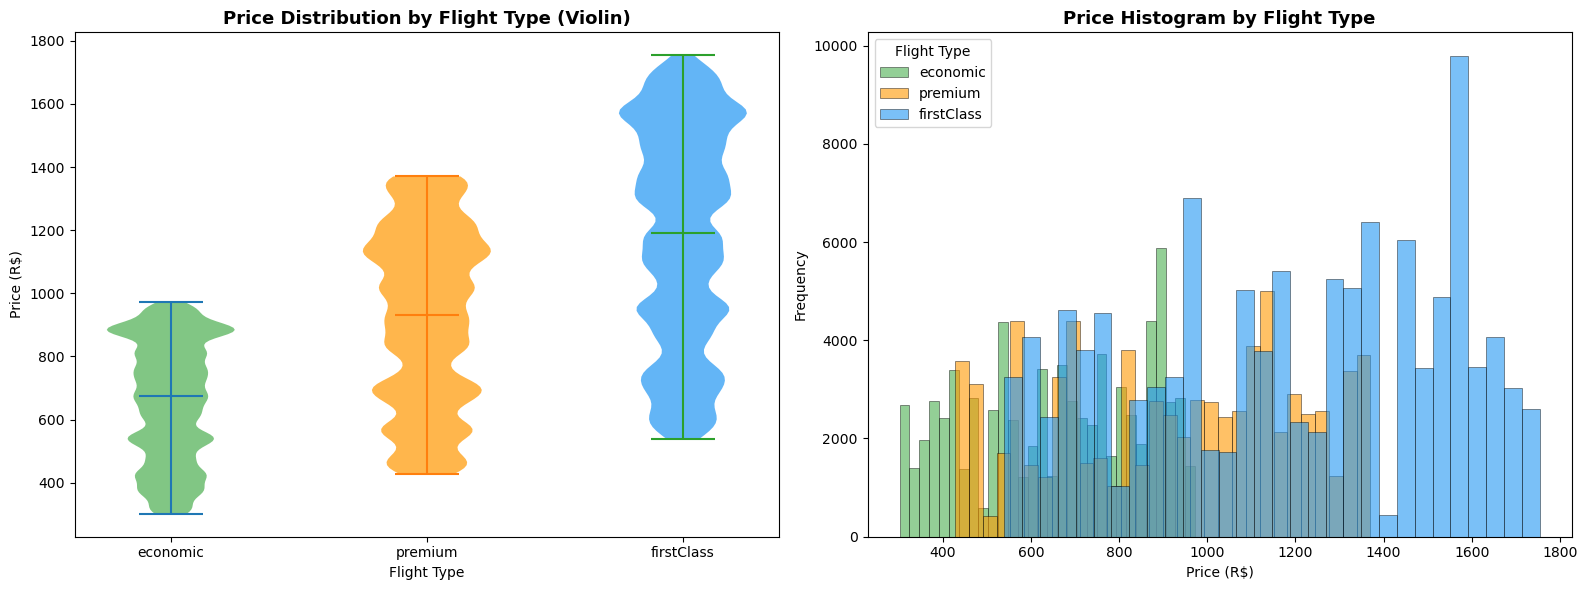

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Violin plot
flight_type_order = ['economic', 'premium', 'firstClass']
colors = ['#4CAF50', '#FF9800', '#2196F3']

for i, (ft, color) in enumerate(zip(flight_type_order, colors)):
    data = flights_df[flights_df['flightType'] == ft]['price']
    parts = axes[0].violinplot(data, positions=[i], showmedians=True, showextrema=True)
    for pc in parts['bodies']:
        pc.set_facecolor(color)
        pc.set_alpha(0.7)

axes[0].set_xticks(range(len(flight_type_order)))
axes[0].set_xticklabels(flight_type_order)
axes[0].set_title('Price Distribution by Flight Type (Violin)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Flight Type')
axes[0].set_ylabel('Price (R$)')

# Histogram
for ft, color in zip(flight_type_order, colors):
    data = flights_df[flights_df['flightType'] == ft]['price']
    axes[1].hist(data, bins=30, color=color, alpha=0.6, label=ft, edgecolor='black', linewidth=0.5)

axes[1].set_title('Price Histogram by Flight Type', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Price (R$)')
axes[1].set_ylabel('Frequency')
axes[1].legend(title='Flight Type')

plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?
Violin plots show full distribution shape (including bimodality) which box plots miss. Histograms complement by showing the exact frequency. Together they provide a complete picture of price distribution.

##### 2. What is/are the insight(s) found from the chart?
- **FirstClass** tickets have the highest price range with greater spread — indicating variable premium pricing.
- **Economic** tickets cluster at lower price ranges, showing standardized competitive pricing.
- **Premium** falls in between, with a relatively tighter distribution.

##### 3. Will the gained insights help creating a positive business impact?
Yes! Understanding price ranges helps agencies set dynamic pricing strategies, establish price floors/ceilings, and identify price-sensitive customer segments.


#### Chart - 8 - Hotel Spending Analysis (Bivariate)


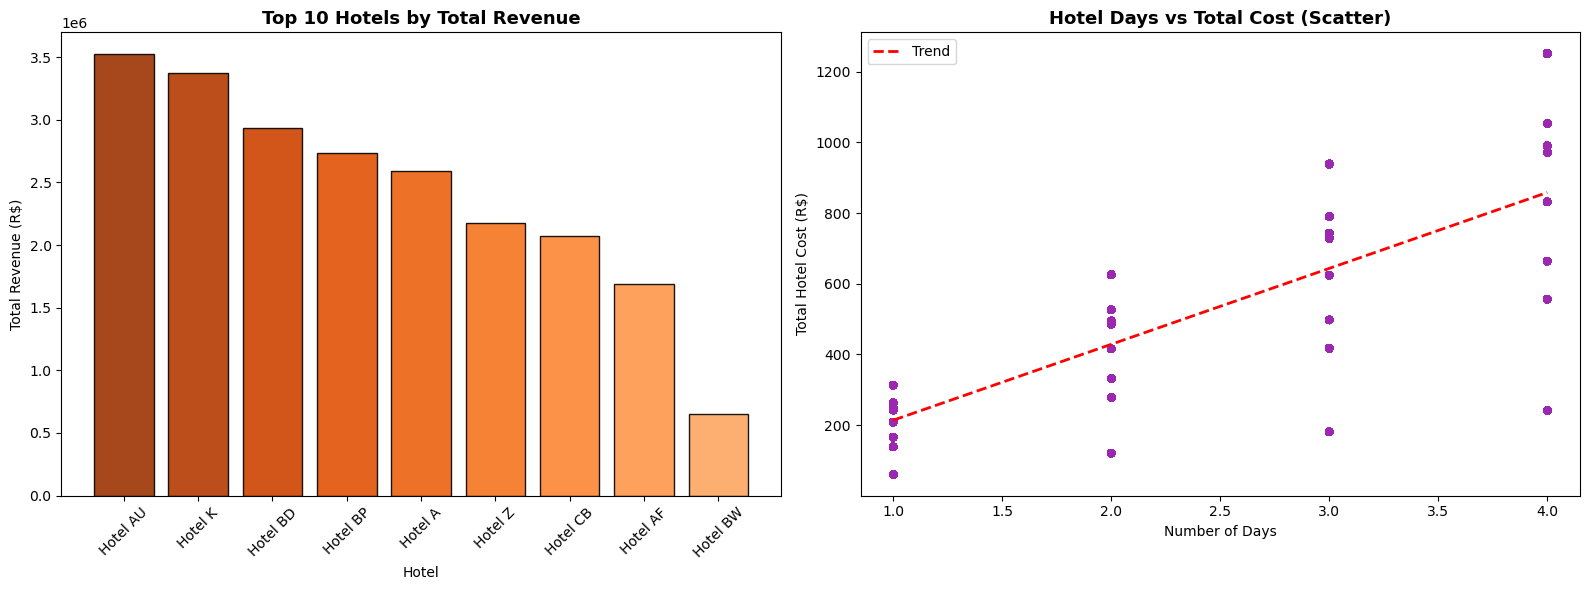

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top hotels by total revenue
hotel_revenue = hotels_df.groupby('name')['total'].sum().sort_values(ascending=False).head(10)
axes[0].bar(hotel_revenue.index, hotel_revenue.values,
            color=plt.cm.Oranges(np.linspace(0.4, 0.9, len(hotel_revenue))[::-1]),
            edgecolor='black', alpha=0.9)
axes[0].set_title('Top 10 Hotels by Total Revenue', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Hotel')
axes[0].set_ylabel('Total Revenue (R$)')
axes[0].tick_params(axis='x', rotation=45)

# Average hotel price per night vs number of days
axes[1].scatter(hotels_df['days'], hotels_df['total'], alpha=0.3, c='#9C27B0', edgecolors='none')
axes[1].set_title('Hotel Days vs Total Cost (Scatter)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Days')
axes[1].set_ylabel('Total Hotel Cost (R$)')
# Add trend line
z = np.polyfit(hotels_df['days'], hotels_df['total'], 1)
p = np.poly1d(z)
x_line = np.linspace(hotels_df['days'].min(), hotels_df['days'].max(), 100)
axes[1].plot(x_line, p(x_line), 'r--', linewidth=2, label='Trend')
axes[1].legend()

plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?
Bar charts for hotel revenue ranking and scatter plots for relationship analysis between days and total cost. The trend line in the scatter plot immediately reveals the linear relationship.

##### 2. What is/are the insight(s) found from the chart?
- **Hotel K** (Salvador) and **Hotel A** (Florianopolis) are top revenue generators due to their high per-night prices and frequent bookings.
- Total hotel cost has a strong positive linear relationship with number of days — as expected, but the slope varies by hotel (some are significantly more expensive per night).

##### 3. Will the gained insights help creating a positive business impact?
Yes! Hotels with high revenue are key partners — agencies can negotiate exclusive deals. Understanding the days-cost relationship helps in bundling flight+hotel packages.


#### Chart - 9 - Gender vs Flight Type & Age Group Analysis (Multivariate)


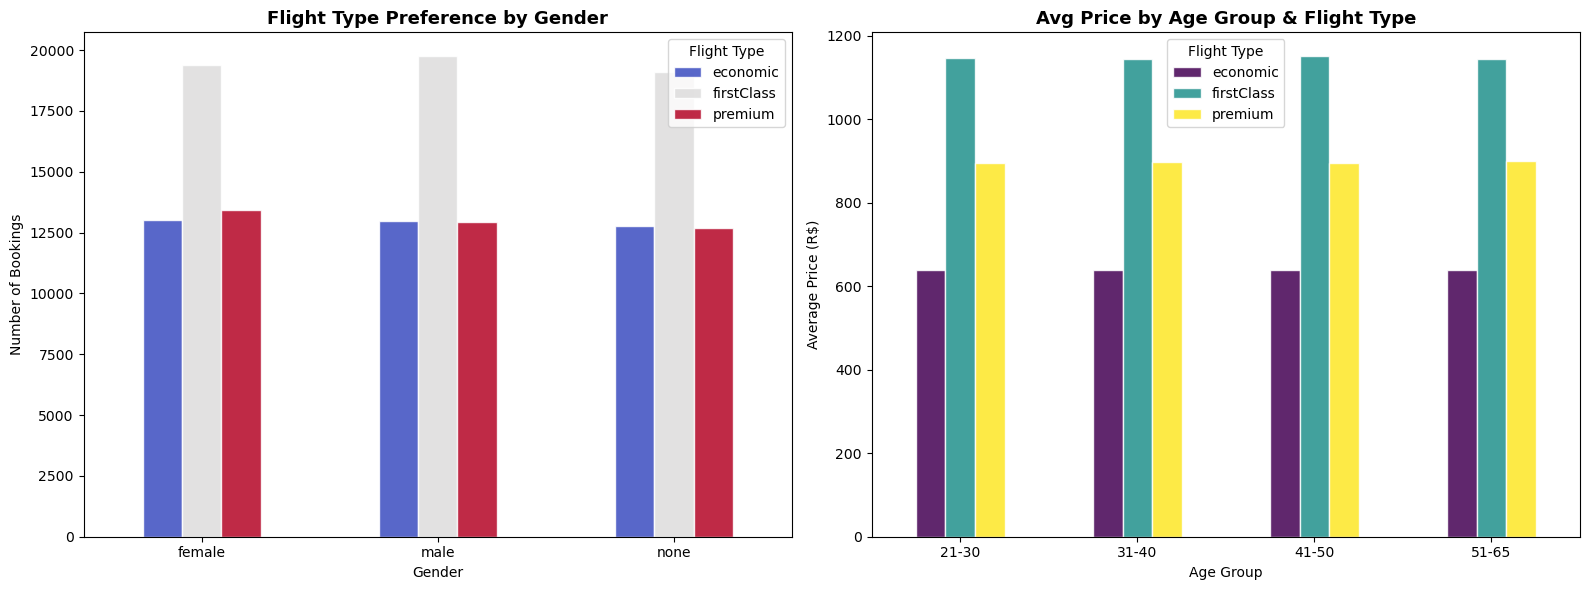

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gender vs flight type
gender_flight = flights_users.groupby(['gender', 'flightType']).size().reset_index(name='count')
pivot_gender = gender_flight.pivot(index='gender', columns='flightType', values='count').fillna(0)
pivot_gender.plot(kind='bar', ax=axes[0], colormap='coolwarm', edgecolor='white', alpha=0.85)
axes[0].set_title('Flight Type Preference by Gender', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Number of Bookings')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Flight Type')

# Age group vs average price
age_price = flights_users.groupby(['age_group', 'flightType'])['price'].mean().reset_index()
pivot_age = age_price.pivot(index='age_group', columns='flightType', values='price')
pivot_age.plot(kind='bar', ax=axes[1], colormap='viridis', edgecolor='white', alpha=0.85)
axes[1].set_title('Avg Price by Age Group & Flight Type', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Average Price (R$)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Flight Type')

plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?
Grouped bar charts allow direct comparison across multiple categories simultaneously (gender/age group vs flight type). This reveals demographic patterns in travel behavior.

##### 2. What is/are the insight(s) found from the chart?
- Flight type distribution is relatively similar across genders — no strong gender-based preference for class of travel.
- Users who did not disclose gender ('none') represent a significant booking segment.
- Older age groups (51-65) tend to pay slightly higher average prices, consistent with higher firstClass usage.

##### 3. Will the gained insights help creating a positive business impact?
Yes! Age-based pricing and loyalty tiers can be implemented. The 'none' gender group is significant — agencies should not exclude them from any promotional campaigns.


#### Chart - 10 - Correlation Heatmap


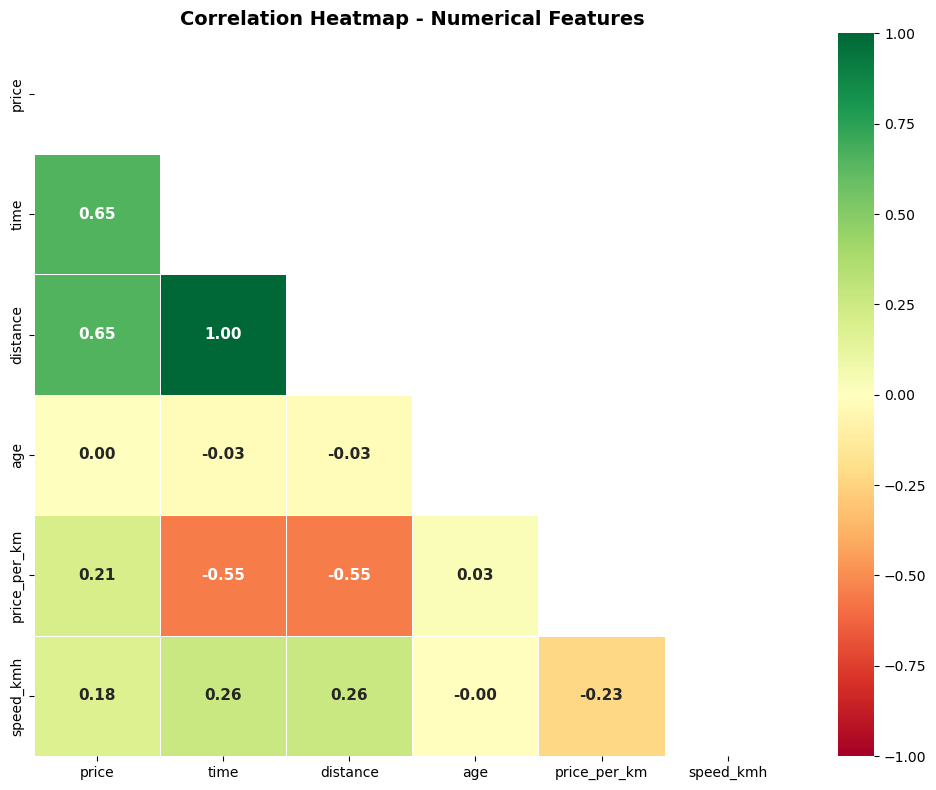

In [24]:
# Select numerical features for correlation
num_features = ['price', 'time', 'distance', 'age', 'price_per_km', 'speed_kmh']
corr_data = flights_users[num_features].dropna()
corr_matrix = corr_data.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, ax=ax, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 11, 'weight': 'bold'})
ax.set_title('Correlation Heatmap - Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?
Correlation heatmaps provide a quick overview of linear relationships between all numerical features simultaneously. The color scale makes strong correlations immediately visible.

##### 2. What is/are the insight(s) found from the chart?
- **Distance and Time** are highly positively correlated — longer routes take more time (expected).
- **Price** is moderately correlated with **distance** and **time** — longer/slower routes cost more.
- **price_per_km** has an inverse relationship with distance — bulk discount effect over longer distances.
- **Age** shows low correlation with price features, confirming that age alone is not a strong predictor of spending.

##### 3. Will the gained insights help creating a positive business impact?
Yes! The distance-time-price relationship can be used to build pricing models. The low correlation of age with price suggests pricing should be based on route and class, not demographics.


#### Chart - 11 - Distance vs Price Scatter (Bivariate) with Flight Type Color


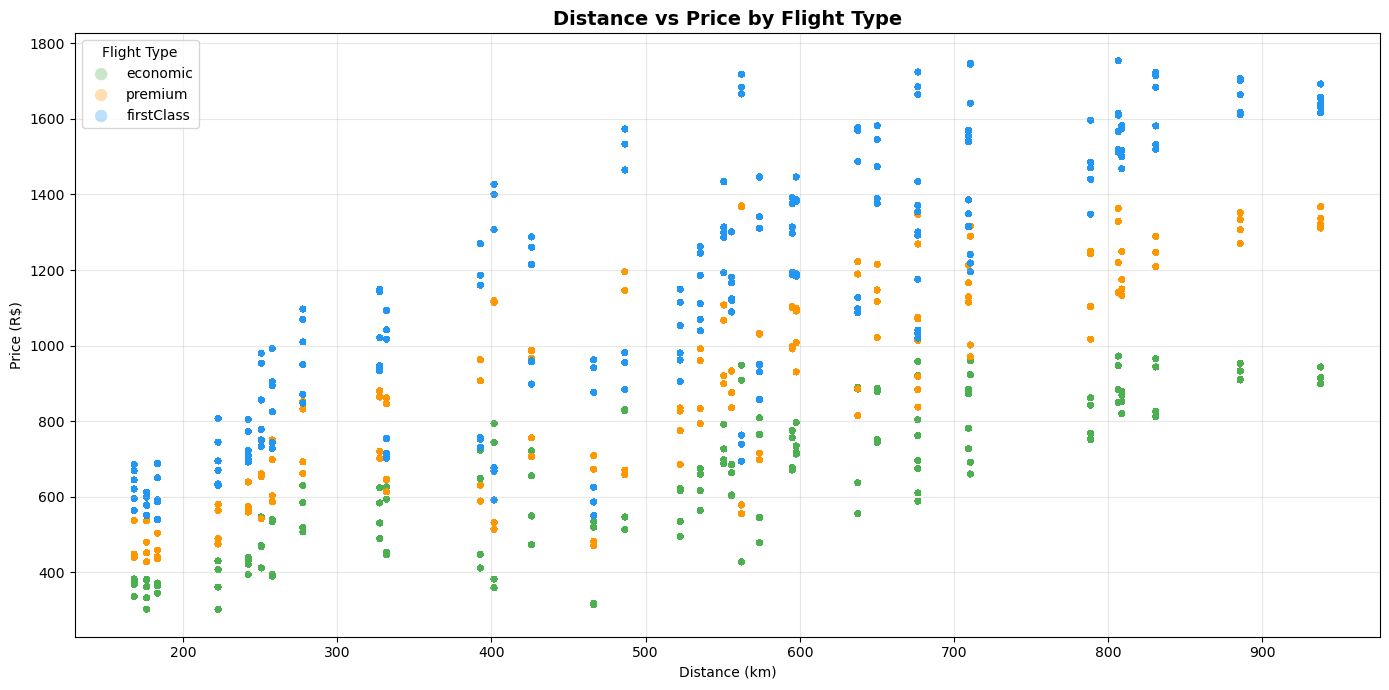

In [25]:
fig, ax = plt.subplots(figsize=(14, 7))

colors_map = {'economic': '#4CAF50', 'premium': '#FF9800', 'firstClass': '#2196F3'}

for ft, color in colors_map.items():
    subset = flights_df[flights_df['flightType'] == ft]
    ax.scatter(subset['distance'], subset['price'], alpha=0.3, c=color,
               label=ft, edgecolors='none', s=20)

ax.set_title('Distance vs Price by Flight Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Distance (km)')
ax.set_ylabel('Price (R$)')
ax.legend(title='Flight Type', markerscale=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?
A colored scatter plot allows simultaneous visualization of three variables: distance, price, and flight type. It's the ideal chart for revealing how these three interact.

##### 2. What is/are the insight(s) found from the chart?
- FirstClass tickets cluster at higher prices across all distances — confirming the premium pricing.
- Economic tickets have prices that increase with distance but remain below firstClass.
- There's significant price overlap between premium and firstClass at shorter distances.
- Some routes show notably high prices regardless of distance — possibly due to route monopoly or peak season pricing.


## **5. Solution to Business Objective**


#### What do you suggest the client to achieve Business Objective?


Based on the EDA analysis, here are the key recommendations for the travel agency to achieve its business objectives:

**1. Customer Segmentation & Targeting:**
- Segment customers by **age group** (21-30: budget travelers; 51-65: premium travelers) and create targeted marketing campaigns.
- Corporate accounts (identified by company) should receive dedicated account managers and exclusive firstClass/premium deals.
- The gender-neutral segment ('none') is significant — ensure inclusive marketing.

**2. Agency Partnership Optimization:**
- Prioritize **CloudFy** for high-volume economic bookings and **FlyingDrops** for premium/firstClass luxury packages.
- Negotiate exclusive deals with top-performing agencies on popular routes.

**3. Route Strategy:**
- Focus marketing and seat inventory on the top 15 most booked routes.
- For less popular routes, consider package deals (flight + hotel bundles) to increase demand.

**4. Hotel Partnerships:**
- Partner closely with **Hotel K** (Salvador) and **Hotel A** (Florianopolis) as they generate the highest hotel revenue.
- Bundle high-demand flights with partner hotels for package deals.

**5. Seasonal Revenue Management:**
- Use time series insights to launch promotional campaigns during low booking periods.
- Increase prices dynamically during peak months to maximize revenue.

**6. Pricing Strategy:**
- Use the distance-price relationship to build a fair and transparent pricing model.
- Offer `price_per_km` discounts for long-distance routes to attract more bookings on underutilized corridors.


# **Conclusion**


This EDA of the travel dataset revealed several critical insights:

1. **Flight Type Distribution**: Economic class dominates bookings, but firstClass generates higher revenue per booking — balancing both is key.

2. **Agency Performance**: CloudFy leads in volume, FlyingDrops in premium pricing. Different agencies serve different market segments effectively.

3. **Route Analysis**: A small set of routes (Brasilia, Recife, Sao Paulo corridors) account for the majority of bookings — these are the business backbone.

4. **Demographics**: Age and gender have moderate influence on travel spending. Corporate accounts are the highest value customers.

5. **Hotel Correlation**: Hotel bookings correlate with flight bookings but not 1:1 — there's an opportunity to increase hotel attachment rates through bundling.

6. **Pricing Patterns**: Price scales with distance and flight type as expected, with firstClass commanding significant premiums across all routes.

The next step is to build a **Machine Learning model** that can predict flight type preference and travel spending based on user demographics and route characteristics — enabling proactive personalization of travel recommendations.

---
### ***Hurrah! You have successfully completed your Travel EDA Capstone Project !!!***
